# **📊 E-Commerce Datenanalyse: Logistik, Kundenzufriedenheit und Reputationsrisiken**

Projekt-Status: 🟢 Aktiv (Work in Progress)

📌  Projektziel und Forschungsfokus
Das primäre Ziel dieses Projekts ist eine umfassende, datengestützte Untersuchung der kausalen Zusammenhänge zwischen operativen Kernprozessen (Logistik und Händlerqualität) und der daraus resultierenden Kundenzufriedenheit auf der Olist-Plattform. Die Analyse dient dem Zweck, die mathematischen Dynamiken zwischen betrieblichen Kennzahlen und Nutzerbewertungen zu entschlüsseln, um fundierte Grundlagen für strategische Management-Entscheidungen zu schaffen.



🛠 Tech Stack Sprache: Python

Data Manipulation: Pandas, NumPy

Datenvisualisierung: Matplotlib, Seaborn

Methodik: Agiles Projektmanagement, Explorative Datenanalyse (EDA)

# 📑  Inhaltsverzeichnis und Forschungsfragen
 [Teil 1: Abhängigkeit zwischen Lieferzeit und Kundenzufriedenheit](#1)

* Zentrale Forschungsfrage: Wie skaliert die Kundenzufriedenheit mit jedem zusätzlichen Tag Lieferzeit und ab welchem Punkt kippt die Bewertung ins Negative?
 
 [Teil 2: Untersuchung der Kundenloyalität und Validierung des Einmalkäufer Modells](#2)

 * Zentrale Forschungsfrage: Beeinflusst die Erfahrung der ersten Bestellung die Retention-Rate oder operiert die Plattform strukturell als reines Einmalkäufer-Modell?
 
 [Teil 3: Analyse der Lieferverzögerung und mathematischer Nachweis des Erwartungsbruchs](#3)

 * Zentrale Forschungsfrage: Was triggert toxische Bewertungen stärker: Die absolute Langsamkeit der Lieferung oder der mathematische Bruch des dem Kunden gegebenen Lieferversprechens?
   
 [Teil 4: Wirtschaftliche Relevanz der Verkäuferqualität und Identifikation operativer Risikoträger](#4)

 * Zentrale Forschungsfrage: Welchen finanziellen und reputativen Einfluss haben qualitative Minderperformer auf das Gesamtökosystem der Plattform?
   

    [Teil 4.1: Asymmetrische Verteilung des Reputationsschadens durch Minderperformer](#4.1)


   * Zentrale Forschungsfrage: Wie ungleich ist der Reputationsschaden auf der Plattform verteilt und in welchem Maße verzerren wenige qualitative Ausreißer (Minderperformer) das algorithmische Gesamtbild der Kundenzufriedenheit?
     
     
 

    [Teil 4.2: Korrelationsanalyse und perzentilbasierte Quadranten Gruppierung der Verkäufer](#4.2)


   * Zentrale Forschungsfrage: Wie stark ist die statistische Abhängigkeit zwischen Verspätungs- und Kritikerquote (Pearson-Korrelation) und wie lassen sich Produktmängel von Logistikfehlern über eine 75.-Perzentil-Quadranten-Analyse isolieren?
     
 

    [Teil 4.3: Kausalanalyse der logistischen Engpässe und Zuordnung der Verantwortung zwischen Carrier und Verkäufer](#4.3)

   * Zentrale Forschungsfrage: Wer trägt die statistische Schuld an harten Lieferverzögerungen: Ist der Engpass primär in der internen Bearbeitungszeit des Händlers oder in der externen Transportkette des Logistikdienstleisters (Carrier) verortet?
     
 

    [Teil 4.4: Umsatzrelevanz minderperformanter Großhändler und Bewertung des Reputationsrisikos](#4.4)

   * Zentrale Forschungsfrage: Welches konkrete finanzielle Volumen (Umsatz- und Bestellanteil) kontrollieren die identifizierten Risiko-Großhändler und wie hoch ist der exakte wirtschaftliche Hebel dieser qualitativen Ausreißer auf das Gesamtsystem?
 

 [Teil 5: Synthese der Ergebnisse und Strategischer Aktionsplan](#5)

 * Zentrale Forschungsfrage: Wie lassen sich die in den vorherigen Phasen empirisch nachgewiesenen Datenwerte strategisch nutzen, um den Plattformumsatz nachhaltig zu sichern, und welche datenbasierten Maßnahmen müssen ergriffen werden, um die Neukundenakquise vor Qualitätsdefiziten zu schützen?

# <a id="teil1"></a>1
#  **Abhängigkeit zwischen Lieferzeit und Kundenzufriedenheit**

Das Problem: Im Online-Handel ist es sehr teuer, neue Kunden zu gewinnen. Deshalb ist es extrem wichtig, dass bestehende Kunden zufrieden sind und wieder einkaufen. Wenn Kunden wegen langen Lieferzeiten unzufrieden sind und nicht mehr bestellen, verliert das Unternehmen viel Geld.

Unsere Forschungsfrage: Welchen messbaren Einfluss hat die Lieferzeit auf die vergebenen Sterne-Bewertungen? Wir wollen den exakten Trend Tag für Tag sichtbar machen. Das Ziel ist es, dem Management mit echten Daten zu beweisen, wie schnell Pakete ankommen müssen, um die Zufriedenheit auf einem profitablen Niveau zu halten.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


### **Schritt 1: Daten-Import und Qualitätskontrolle**
Die Rohdaten werden geladen. Im Anschluss suchen wir nach Fehlern oder fehlenden Werten in der Tabelle und machen die Daten sauber. Das ist das Fundament für unsere Analyse.

In [2]:
# Kundendaten laden und die ersten 5 Zeilen prüfen
kunden = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv')
kunden.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [3]:
#  Fehlende Werte prüfen
kunden.isnull().sum()


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [4]:
# Bestellungendaten  laden und die ersten 5 Zeilen prüfen
bestellungen = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')
bestellungen.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
#  Fehlende Werte prüfen
bestellungen.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [6]:
# Fehlende Werte löschen und nochmal prüfen
bestellungen.dropna(subset=['order_delivered_customer_date'], inplace=True)
bestellungen.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
dtype: int64

In [7]:
#  Das Kaufdatum von Text in ein echtes Datum weckseln
bestellungen['order_purchase_timestamp'] = pd.to_datetime(bestellungen['order_purchase_timestamp'])

#  Das Lieferdatum von Text in ein echtes Datum weckseln
bestellungen['order_delivered_customer_date'] = pd.to_datetime(bestellungen['order_delivered_customer_date'])

# Kontrollieren
bestellungen.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96476 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96476 non-null  object        
 1   customer_id                    96476 non-null  object        
 2   order_status                   96476 non-null  object        
 3   order_purchase_timestamp       96476 non-null  datetime64[ns]
 4   order_approved_at              96462 non-null  object        
 5   order_delivered_carrier_date   96475 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96476 non-null  object        
dtypes: datetime64[ns](2), object(6)
memory usage: 6.6+ MB


### **Schritt 2: Die Master-Tabelle erstellen**
Die sauberen Einzel-Tabellen werden jetzt zu einer großen Haupt-Tabelle verschmolzen. Als Verbindungsstück zwischen den Tabellen nutzen wir die Spalte `customer_id`. Ab jetzt arbeiten wir nur noch mit dieser zusammengefassten Master-Tabelle.

In [8]:
# Verschmelzen Bestellungen und Kunden zu einer neuen Master-Tabelle
master_tabelle = pd.merge(bestellungen, kunden, on='customer_id', how='inner')
master_tabelle.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


### **Schritt 3: Berechnung der Lieferdauer in Tagen**
Wir erschaffen eine neue Daten-Spalte. Dafür rechnet das System: "Lieferdatum minus Kaufdatum". Das Ergebnis zeigt uns die exakten Liefertage an.

In [9]:
# berechnen  Lieferzeit in Tagen 
master_tabelle['lieferzeit_tage'] = (master_tabelle['order_delivered_customer_date'] - master_tabelle['order_purchase_timestamp']).dt.days

# prüfen mithilfe den relevanten Spalten
master_tabelle[['order_purchase_timestamp', 'order_delivered_customer_date', 'lieferzeit_tage']].head(10)

,order_purchase_timestamp,order_delivered_customer_date,lieferzeit_tage
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2
5,2017-07-09 21:57:05,2017-07-26 10:57:55,16
6,2017-05-16 13:10:30,2017-05-26 12:55:51,9
7,2017-01-23 18:29:09,2017-02-02 14:08:10,9
8,2017-07-29 11:55:02,2017-08-16 17:14:30,18
9,2017-05-16 19:41:10,2017-05-29 11:18:31,12


### **Schritt 4: Kundenbewertungen laden und isolieren**
Die Lieferzeit allein reicht nicht aus. Wir müssen wissen, wie zufrieden die Kunden waren. Dafür laden wir die Tabelle mit den Bewertungen (1 bis 5 Sterne). Wir filtern sofort die zwei wichtigsten Spalten heraus (Bestellnummer und Sterne) und prüfen diese auf leere Felder, um sauber weiterarbeiten zu können.

In [10]:
# Bewertungsdaten laden 
bewertungen = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv')
# Isolieren mit Variablen order_ID und review_score 
bewertungen_isoliert = bewertungen[['order_id', 'review_score']]
# prüfen
bewertungen_isoliert.head()
# prüfen Sauberkeit
bewertungen_isoliert.isnull().sum()

order_id        0
review_score    0
dtype: int64

### **Schritt 5: Tabellen zusammenfügen**
Wir verbinden die Bewertungen über die Bestellnummer (`order_id`) mit unserer Master-Tabelle. So haben wir Lieferdauer und Sterne-Bewertung endlich zusammen an einem Ort.

In [11]:
# Verschmelzen (Merge)  master_tabelle und bewertungen_isoliert
finale_tabelle = pd.merge(master_tabelle, bewertungen_isoliert, on='order_id', how='inner')
# prüfen
finale_tabelle.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,lieferzeit_tage,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,8,4
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,13,4
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,9,5
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,13,5
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2,5


### **Schritt 6: Den Durchschnitt berechnen (Daten zusammenfassen)**
Um ein klares Muster zu erkennen, fassen wir die Daten zusammen. Wir berechnen für jeden einzelnen Liefer-Tag den Durchschnitt der Sterne-Bewertungen. Das ist das finale Fundament für unser Diagramm.

In [12]:
# Durchschnittliche Sterne pro Liefer-Tag berechnen
bewertung_pro_tag = finale_tabelle.groupby('lieferzeit_tage')['review_score'].mean().reset_index()
# runden die Ergebnisse mit 2
bewertung_pro_tag['review_score'] = bewertung_pro_tag['review_score'].round(2)
# prüfen
bewertung_pro_tag.head(10)

,lieferzeit_tage,review_score
0,0,4.23
1,1,4.50
2,2,4.48
3,3,4.43
4,4,4.43
5,5,4.39
6,6,4.38
7,7,4.38
8,8,4.35
9,9,4.30


### **Schritt 7: Daten visualisieren (Liniendiagramm)**
Tabellen sind schwer zu lesen. Wir wandeln unsere Daten jetzt in ein klares Liniendiagramm um (Fokus auf die ersten 30 Tage). So sehen wir den Trend der Zufriedenheit auf einen Blick.

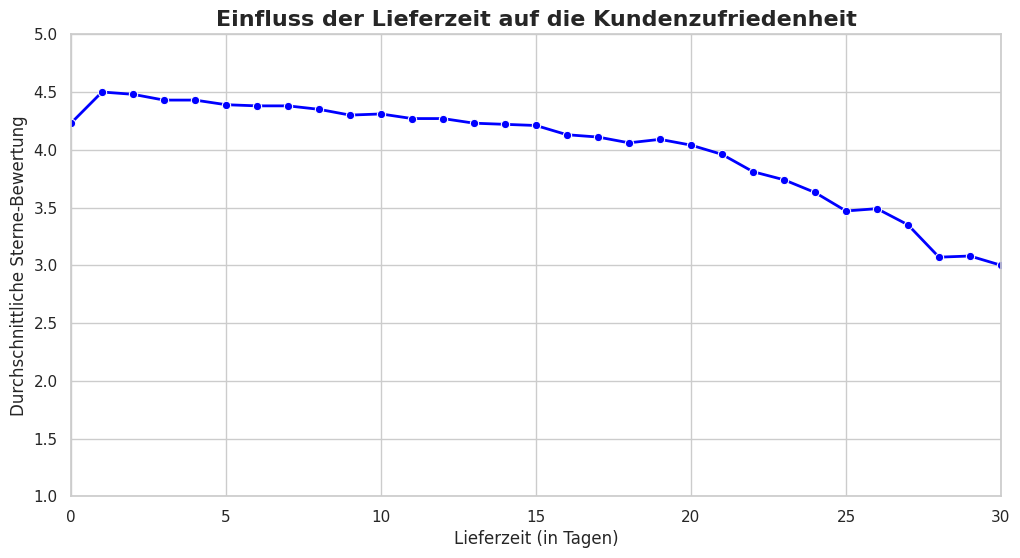

In [13]:
# Wichtige Bibliotheken für Grafiken laden
import matplotlib.pyplot as plt
import seaborn as sns

# Ein sauberes Design auswählen
sns.set_theme(style="whitegrid")

# Die Größe des Diagramms festlegen
plt.figure(figsize=(12, 6))

# Das reine Liniendiagramm zeichnen
sns.lineplot(data=bewertung_pro_tag, x='lieferzeit_tage', y='review_score', marker='o', color='blue', linewidth=2)

# Titel und Achsen beschriften
plt.title('Einfluss der Lieferzeit auf die Kundenzufriedenheit', fontsize=16, fontweight='bold')
plt.xlabel('Lieferzeit (in Tagen)', fontsize=12)
plt.ylabel('Durchschnittliche Sterne-Bewertung', fontsize=12)

# Achsen-Grenzen festlegen (Nur bis Tag 30, Sterne von 1 bis 5)
plt.xlim(0, 30)
plt.ylim(1, 5)

# Diagramm anzeigen
plt.show()

### Fazit zu Frage 1: Was uns das Diagramm zeigt

**1. Die generelle Übersicht und der Ergebnis**
Das Diagramm zeigt ein sehr klares Bild: Je länger ein Kunde auf sein Paket wartet, desto schlechter wird die Bewertung. 
* Bei einer sehr schnellen Lieferung (1 bis 4 Tage) sind die Kunden am glücklichsten und geben im Durchschnitt fast 4,5 Sterne. 
* Danach geht die Linie eindeutig und konstant nach unten. Bei 30 Tagen Wartezeit sind wir bereits bei nur noch 3 Sternen angekommen.

**2. Warum ist die Linie nicht perfekt glatt?**
 Die Kunden bewerten nicht *nur* die Lieferzeit. Ein Paket kann super schnell ankommen, aber wenn das Produkt kaputt ist oder der Paketbote unfreundlich war, gibt es trotzdem nur 1 Stern. Das sorgt für die kleinen Schwankungen in unserer Linie.
 
* **Das Rätsel um "Tag 0":** Warum ist eine Lieferzeit von 0 Tagen (4.23 Sterne) schlechter als 1 Tag (4.50 Sterne)? In der Realität bedeutet "0 Tage" oft, dass es Probleme gab. Zum Beispiel hat der Kunde die Bestellung sofort wieder storniert oder das System hatte einen Fehler. Das macht Kunden wütend und drückt den Durchschnitt nach unten.
* Diese Datensätze wurden bewusst nicht aus der Analyse entfernt, um die prozessualen Systemfehler und Stornierungsanomalien der Olist-Plattform transparent aufzuzeigen, anstatt die Datenbasis künstlich zu glätten.


# <a id="teil2"></a>2
# **Untersuchung der Kundenloyalität und Validierung des Einmalkäufer Modells**

 

### **Hypothesentest – Der Einfluss der Kundenzufriedenheit auf die Kundenbindung**

**Die Forschungsfrage (Hypothese):**
Ziel dieses Abschnitts ist es, die wissenschaftliche Korrelation zwischen der ersten Kundenerfahrung (Sterne-Bewertung) und der Wahrscheinlichkeit eines erneuten Kaufs (Retention Rate) zu untersuchen. Die logische Ausgangshypothese lautet: Eine hohe Zufriedenheit führt zu einer höheren Kundenbindung.

**Technische Vorbereitung der Daten:**
Bevor wir die Berechnungen durchführen können, müssen wir die relevanten Tabellen korrekt zusammenführen (Mergen). Dabei gibt es eine strukturelle Besonderheit im Datensatz: Das System generiert für jede einzelne Bestellung eine neue `customer_id`. Um echte Wiederkäufer über einen längeren Zeitraum zu identifizieren, müssen wir stattdessen den übergeordneten Schlüssel `customer_unique_id` nutzen. 

Im folgenden Codeblock laden wir die Datensätze und verschaffen uns eine Übersicht, um die exakten Verknüpfungspunkte für unseren Hypothesentest zu finden.

Wir haben den echten Menschen (customer_unique_id) in der Tabelle Kunden.

Wir haben das Bestellticket (order_id) in der Tabelle Bestellungen. Die Brücke dorthin ist die customer_id.

Wir haben die Sterne (review_score) in der Tabelle Bewertungen. Die Brücke dorthin ist die order_id.

In [14]:
# Alle Dateien laden wir einzeln
import pandas as pd

kunden = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv')
bestellungen = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')
verkäufer = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv')
bewertungen = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv')
bestell_artikeln = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv')
produkte = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv')
geodaten = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv')
product_kategorien = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv')
zahlungen = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv')

# Das Dictionary: Hier verbinden wir den NAMEN mit den DATEN
# Das ist wie ein Inhaltsverzeichnis für die Tabellen
alle_dateien = {
    "Kunden": kunden,
    "Bestellungen": bestellungen,
    "Verkäufer": verkäufer,
    "Bewertungen": bewertungen,
    "Artikel": bestell_artikeln,
    "Produkte": produkte,
    "Geodaten": geodaten,
    "Kategorien": product_kategorien,
    "Zahlungen": zahlungen
}

# Die Schleife: Wir gehen durch das Inhaltsverzeichnis
# Hier 'name' bekommt den Text (z.B. "Kunden"), 'df' bekommt die element
for name, df in alle_dateien.items():
    print(f"--- {name} ---")
    display(df.head(0)) # Zeigt nur die Kopfzeile

--- Kunden ---


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


--- Bestellungen ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


--- Verkäufer ---


...

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state


--- Kategorien ---


,product_category_name,product_category_name_english


--- Zahlungen ---


,order_id,payment_sequential,payment_type,payment_installments,payment_value


### **Schritt 1: Daten auf Fehler prüfen**
Bevor wir die Tabellen verbinden, prüfen wir unsere Verbindungsstücke (die IDs) auf leere Felder. Nur mit sauberen IDs funktioniert die Verschmelzung fehlerfrei.

In [15]:
print("--- Fehlende Werte bei Kunden ---")
print(kunden[['customer_id', 'customer_unique_id']].isnull().sum())
print("\n--- Fehlende Werte bei Bestellungen ---")
print(bestellungen[['order_id', 'customer_id']].isnull().sum())
print("\n--- Fehlende Werte bei Bewertungen ---")
print(bewertungen[['order_id', 'review_score']].isnull().sum())

--- Fehlende Werte bei Kunden ---
customer_id           0
customer_unique_id    0
dtype: int64

--- Fehlende Werte bei Bestellungen ---
order_id       0
customer_id    0
dtype: int64

--- Fehlende Werte bei Bewertungen ---
order_id        0
review_score    0
dtype: int64


### **Schritt 2: Einmalkäufer vs. Wiederkäufer zählen**
Da unsere IDs sauber sind, verbinden (mergen) wir nun die Bestellungen mit den Kunden. In dieser neuen Basis-Tabelle schauen wir uns die echte Kunden-ID (`customer_unique_id`) an. Wenn eine ID nur ein einziges Mal in der Liste steht, hat der Kunde nie wieder bestellt (Kundenverlust / Churn). Taucht sie öfter auf, ist es ein Wiederkäufer.

In [16]:
# Verschmelzen von Bestellungen und Kunden über die customer_id
basis_tabelle = pd.merge(bestellungen, kunden, on='customer_id', how='inner')

# Zählen, wie oft jede echte Kunden-ID im System vorkommt
kauf_anzahl = basis_tabelle['customer_unique_id'].value_counts()

# Kunden in zwei Gruppen aufteilen (1 Kauf vs. mehr als 1 Kauf)
einmal_kaeufer = kauf_anzahl[kauf_anzahl == 1]
wieder_kaeufer = kauf_anzahl[kauf_anzahl > 1]

# Wissenschaftliches Ergebnis anzeigen
print(f"Kunden mit genau 1 Einkauf (Abgewandert): {len(einmal_kaeufer)}")
print(f"Kunden mit > 1 Einkauf (Wiederkäufer): {len(wieder_kaeufer)}")

Kunden mit genau 1 Einkauf (Abgewandert): 93099
Kunden mit > 1 Einkauf (Wiederkäufer): 2997


### **Schritt 3: Den "Zettel auf die Stirn" kleben**
Wir wissen jetzt, wer ein Einmalkäufer und wer ein Wiederkäufer ist. Jetzt markieren wir jeden Kunden in unserer Master-Tabelle mit diesem "Etikett" (Wiederkäufer: Ja oder Nein). Danach sortieren wir die Daten nach Datum, um für jeden Kunden isoliert nur die allererste Bestellung zu betrachten.

In [17]:
#  Den Zettel auf die Stirn kleben: Ist die Kunden-ID in unserer Wiederkäufer-Liste? (True/False)
basis_tabelle['ist_wiederkäufer'] = basis_tabelle['customer_unique_id'].isin(wieder_kaeufer.index)

#  Chronologisch sortieren (Älteste Käufe zuerst)
basis_tabelle = basis_tabelle.sort_values(by=['customer_unique_id', 'order_purchase_timestamp'])

#  Wir behalten pro Kunde NUR die allererste Zeile (den allerersten Kauf)
erste_bestellungen = basis_tabelle.drop_duplicates(subset=['customer_unique_id'], keep='first')

#  Jetzt holen wir uns die Sterne-Bewertung für exakt diese erste Bestellung dazu
erste_erfahrung = pd.merge(erste_bestellungen, bewertungen_isoliert, on='order_id', how='inner')

#  Kontrolle: Haben wir für jeden Kunden genau eine Zeile?
print(f"Anzahl der Kunden für die Analyse: {len(erste_erfahrung)}")

Anzahl der Kunden für die Analyse: 95653


### **Schritt 4: Die Töpfe auswerten (Das finale Experiment)**
Jetzt kommt der Moment der Wahrheit: Wir sortieren alle Kunden anhand ihrer allerersten Bewertung in 5 Töpfe (1 bis 5 Sterne). Dann berechnet der Computer für jeden einzelnen Topf: Wie viel Prozent der Kunden darin haben das Etikett "Wiederkäufer = Ja"?

In [18]:
#  Gruppieren nach den 5 Sternen (Die Töpfe)
#  Wir berechnen den Mittelwert (mean) der Spalte 'ist_wiederkäufer'. 
#  Da True=1 und False=0 ist, ergibt der Mittelwert exakt die Prozentzahl!
wiederkauf_rate = erste_erfahrung.groupby('review_score')['ist_wiederkäufer'].mean() * 100

#  Ergebnis runden und als Prozent anzeigen
wiederkauf_rate = wiederkauf_rate.round(2)

print("--- WIEDERKAUF-RATE NACH DEM 1. EINDRUCK ---")
for sterne, prozent in wiederkauf_rate.items():
    print(f"Kunden, die beim 1. Mal {sterne} Sterne gaben, kamen zu {prozent} % wieder.")

--- WIEDERKAUF-RATE NACH DEM 1. EINDRUCK ---
Kunden, die beim 1. Mal 1 Sterne gaben, kamen zu 3.35 % wieder.
Kunden, die beim 1. Mal 2 Sterne gaben, kamen zu 3.22 % wieder.
Kunden, die beim 1. Mal 3 Sterne gaben, kamen zu 3.26 % wieder.
Kunden, die beim 1. Mal 4 Sterne gaben, kamen zu 3.06 % wieder.
Kunden, die beim 1. Mal 5 Sterne gaben, kamen zu 3.42 % wieder.


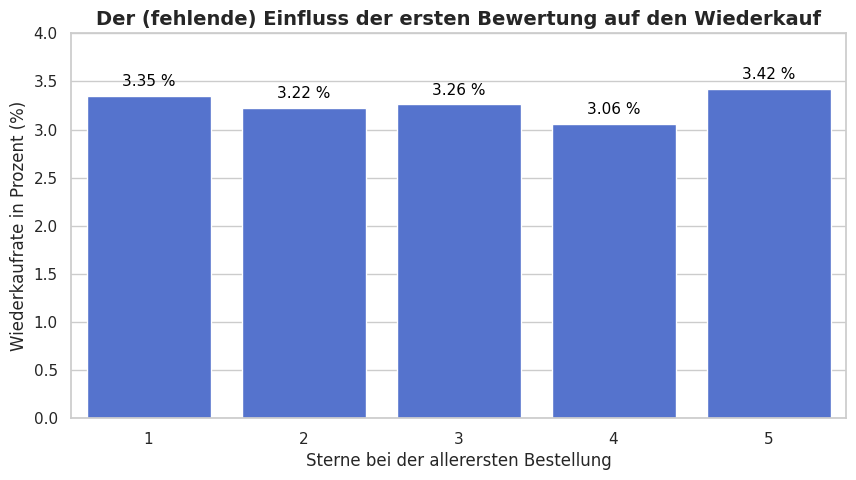

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ein sauberes Design wählen
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Das Balkendiagramm zeichnen (x = Sterne, y = Prozent)
ax = sns.barplot(x=wiederkauf_rate.index, y=wiederkauf_rate.values, color="royalblue")# Titel und Beschriftungen
plt.title('Der (fehlende) Einfluss der ersten Bewertung auf den Wiederkauf', fontsize=14, fontweight='bold')
plt.xlabel('Sterne bei der allerersten Bestellung', fontsize=12)
plt.ylabel('Wiederkaufrate in Prozent (%)', fontsize=12)

# Die genauen Prozentzahlen über die Balken schreiben, damit es richtig gut aussieht
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f} %", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

# Den Y-Achsen-Bereich leicht anpassen, damit die kleinen Unterschiede sichtbar werden
plt.ylim(0, 4)

plt.show()

### Fazit zu Schritt 4: Ein überraschendes Ergebnis
Das Diagramm zeigt uns eine harte wissenschaftliche Wahrheit: Die Sterne-Bewertung hat fast keinen Einfluss auf die Wiederkaufrate. Egal ob der Kunde sein erstes Paket liebt (5 Sterne) oder hasst (1 Stern), die Chance auf einen zweiten Kauf bleibt fast gleich niedrig (knapp über 3 %). Der Grund dafür ist das Marktplatz-Geschäftsmodell, bei dem Kunden generell nur für Einzelkäufe kommen.

Da wir hier an eine analytische Grenze stoßen, wechseln wir nun die Methode. Wir drehen die Perspektive komplett um und schauen uns das Problem von der anderen Seite an.

### **Schritt 5: Die Perspektive wechseln (Sterne-Verteilung pro Gruppe)**
Wir drehen die Frage um. Anstatt zu fragen, wie viele 5-Sterne-Bewerter zurückkommen, fragen wir: "Aus welchen Erstbewertungen setzen sich unsere treuen Wiederkäufer eigentlich zusammen?" Dafür vergleichen wir die prozentuale Sterne-Verteilung der Einmalkäufer direkt mit der Verteilung der Wiederkäufer.

In [20]:
# 1. Wir trennen unsere Master-Tabelle in zwei separate Gruppen
einmal_gruppe = erste_erfahrung[erste_erfahrung['ist_wiederkäufer'] == False]
wieder_gruppe = erste_erfahrung[erste_erfahrung['ist_wiederkäufer'] == True]

# 2. Wir berechnen für jede Gruppe, wie viel Prozent 1, 2, 3, 4 oder 5 Sterne gaben.
# normalize=True rechnet automatisch den prozentualen Anteil aus (anstatt nur zu zählen).
verteilung_einmal = (einmal_gruppe['review_score'].value_counts(normalize=True) * 100).sort_index()
verteilung_wieder = (wieder_gruppe['review_score'].value_counts(normalize=True) * 100).sort_index()

# 3. Wir packen beide Ergebnisse in eine übersichtliche Tabelle zum direkten Vergleich
vergleichs_tabelle = pd.DataFrame({
    'Einmalkäufer (%)': verteilung_einmal.round(2),
    'Wiederkäufer (%)': verteilung_wieder.round(2)
})

# Tabelle hübsch anzeigen
print("--- VERTEILUNG DER ERSTEN STERNE-BEWERTUNG ---")
display(vergleichs_tabelle)

--- VERTEILUNG DER ERSTEN STERNE-BEWERTUNG ---


,Einmalkäufer (%),Wiederkäufer (%)
review_score,,
1,11.53,11.61
2,3.19,3.08
3,8.25,8.09
4,19.45,17.85
5,57.59,59.36


### **Schritt 6: Der visuelle Beweis**
Um final zu verdeutlichen, dass die Kundenzufriedenheit keinen Einfluss auf die Kundentreue hat, visualisieren wir die Tabelle als gruppiertes Balkendiagramm. Es zeigt eindrucksvoll: Die Sterne-Verteilung ist bei Einmalkäufern und treuen Kunden nahezu identisch.

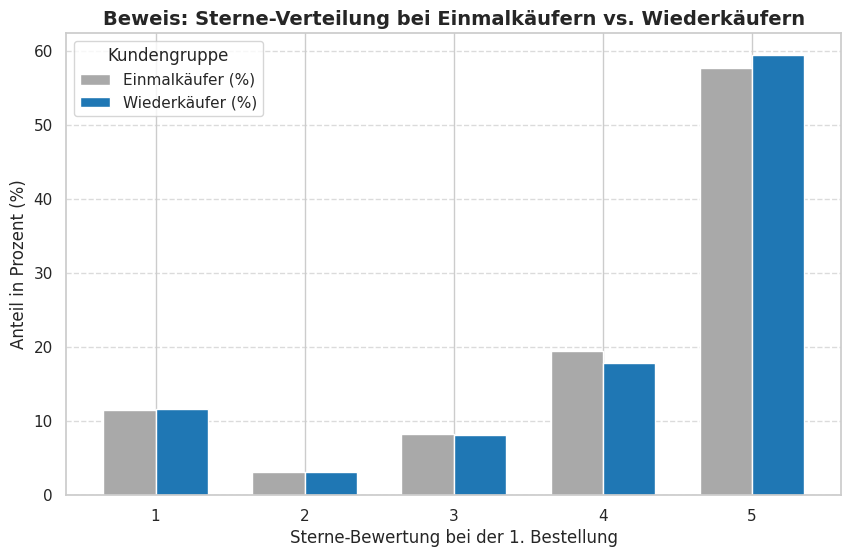

In [21]:
import matplotlib.pyplot as plt

# 1. Wir nutzen die plot-Funktion von Pandas, die automatisch Matplotlib im Hintergrund verwendet
ax = vergleichs_tabelle.plot(kind='bar', figsize=(10, 6), width=0.7, color=['#A9A9A9', '#1f77b4'])

# 2. Titel und Achsen professionell beschriften
plt.title('Beweis: Sterne-Verteilung bei Einmalkäufern vs. Wiederkäufern', fontsize=14, fontweight='bold')
plt.xlabel('Sterne-Bewertung bei der 1. Bestellung', fontsize=12)
plt.ylabel('Anteil in Prozent (%)', fontsize=12)

# 3. Die Zahlen auf der X-Achse (1 bis 5) waagerecht drehen, damit sie lesbar sind
plt.xticks(rotation=0)

# 4. Legende anpassen
plt.legend(title='Kundengruppe', fontsize=11)

# 5. Raster im Hintergrund für den wissenschaftlichen Look
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### **Schritt 7: Warum kommen die Kunden nicht zurück?**

Die bisherige Analyse zeigt ein klares, datengetriebenes Bild: Es gibt prozentual nahezu keinen Unterschied bei der Wiederkaufrate zwischen den verschiedenen Sterne-Bewertungen. Das bedeutet im Umkehrschluss: Ob der Kunde ein perfektes (5 Sterne) oder ein katastrophales (1 Stern) Erlebnis hatte – er kehrt so oder so nicht zurück. 

Um dieses zunächst unlogisch wirkende Verhalten zu erklären, müssen wir das Kernsortiment von Olist analysieren. In welche Konsumkategorie fallen die verkauften Produkte? Handelt es sich um Verbrauchsgüter, die in kurzen Abständen immer wieder neu gekauft werden müssen (z. B. Lebensmittel), oder um langlebige Gebrauchsgüter, die über Jahre hinweg genutzt werden (sodass der Kunde nach einem einmaligen Kauf schlichtweg lange Zeit keinen neuen Bedarf hat)? 

Die folgende Analyse der meistverkauften Kategorien liefert den wissenschaftlichen Beweis zur Beantwortung dieser Frage.

In [22]:

#  Artikel und Produkte verbinden (mit deinen echten Variablennamen)
produkt_verkäufe = pd.merge(bestell_artikeln, produkte, on='product_id', how='inner')

#  Kategorien hinzufügen für englische Namen
produkt_verkäufe_komplett = pd.merge(produkt_verkäufe, product_kategorien, on='product_category_name', how='inner')

#  Top 5 berechnen
top_5_kategorien = produkt_verkäufe_komplett['product_category_name_english'].value_counts().head(5)

#  Anzeigen
print("--- TOP 5 MEISTVERKAUFTE PRODUKTKATEGORIEN ---")
print(top_5_kategorien)

--- TOP 5 MEISTVERKAUFTE PRODUKTKATEGORIEN ---
product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
Name: count, dtype: int64


### Executive Summary (Fazit Teil 2): Die datengetriebene Realität des Geschäftsmodells

Die Daten widerlegen unsere Ausgangshypothese eindeutig: Es gibt keine statistische Korrelation zwischen der Erstbewertung und der Kundenbindung. Sowohl bei katastrophalen (1 Stern) als auch bei perfekten (5 Sterne) Erfahrungen liegt die Wiederkaufrate konstant bei nur rund 3 %. 

**Der wissenschaftliche Beweis:**
Unsere Analyse der Top-5-Kategorien liefert den unwiderlegbaren Beweis für dieses Kundenverhalten. Olist vertreibt primär langlebige Gebrauchsgüter (wie Bettwäsche, Möbel, Sportgeräte und Computerzubehör). Das bedeutet: Olist funktioniert faktisch als reiner Marktplatz für Einmalkäufer. Die Kunden decken einen spezifischen, selten auftretenden Bedarf und haben danach schlichtweg über Jahre hinweg keinen Grund zurückzukehren – völlig unabhängig davon, wie zufrieden sie mit dem Service waren.

**Handlungsempfehlung an das Management:**
Sämtliche Budgets für klassische Kundenbindungsprogramme (z. B. Rabattcodes für den zweiten Einkauf oder Treue-Newsletter) müssen sofort gestoppt werden, da sie in diesem Geschäftsmodell ins Leere laufen. Das Überleben der Firma hängt zu 100 % von der kontinuierlichen Akquise von Neukunden ab. 



# <a id="teil3"></a>3
# **Analyse der Lieferverzögerung und mathematischer Nachweis des Erwartungsbruchs**



**Das geschäftliche Problem:**
Da wir in Teil 2 bewiesen haben, dass Olist fast ausschließlich von Neukunden lebt, ist der öffentliche Ruf (Reviews) die wichtigste Währung des Unternehmens. Wenn zu lange Lieferzeiten zu schlechten Bewertungen führen, schreckt das potenzielle Neukunden ab und gefährdet das gesamte Geschäftsmodell. 

**Die Forschungsfrage:**
In diesem Abschnitt führen wir eine Sentiment-Analyse durch, um das Risiko einer toxischen Bewertung zu quantifizieren. Ab welchem exakten Liefertag kippt die Stimmung der Kunden statistisch ins Negative? Wir suchen den Punkt, an dem das Risiko einer 1-bis-3-Sterne-Bewertung die 50 %-Marke überschreitet.

### **Schritt 1: Definition von „Fan“ vs. „Kritiker“ (Segmentierung)**

In [23]:
#  Wir starten mit einer sauberen Kopie der Bewertungsdaten
df_sentiment = bewertungen.copy()

#  Die harte Gruppierung (Klassifizierung)
# 4 & 5 Punkte = Fan (False)
# 1, 2 & 3 Punkte = Kritiker (True)
df_sentiment['ist_kritiker'] = np.where(df_sentiment['review_score'] <= 3, True, False)

#  Überprüfung der Gruppierung
# Zeige die ersten 10 Zeilen zur Kontrolle
print("--- ERGEBNIS DER GRUPPIERUNG ---")
print(df_sentiment[['review_score', 'ist_kritiker']].head(10))

--- ERGEBNIS DER GRUPPIERUNG ---
   review_score  ist_kritiker
0             4         False
1             5         False
2             5         False
3             5         False
4             5         False
5             1          True
6             5         False
7             5         False
8             5         False
9             4         False


### **Schritt 2: Datenintegration und Kipppunkt-Berechnung**
In diesem Schritt führen wir die Sentiment-Daten mit den Logistik-Informationen zusammen und berechnen die Eskalationsrate der Kundenunzufriedenheit in Abhängigkeit von der Lieferzeit.

Vorgehensweise:

1. Daten-Merge: Zusammenführung von Kundenbewertungen und Bestelldaten.

2. Zeit-Berechnung: Ermittlung der tatsächlichen Lieferdauer in Tagen.

3. Kipppunkt-Aggregation: Berechnung des prozentualen Anteils der Kritiker pro Liefertag.

In [24]:
# 1. Zusammenführung der Daten
df_analyse = pd.merge(df_sentiment, 
                      bestellungen[['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date']], 
                      on='order_id', how='inner')

# 2. Berechnung der Lieferdauer in Tagen
df_analyse['purchase'] = pd.to_datetime(df_analyse['order_purchase_timestamp'])
df_analyse['delivered'] = pd.to_datetime(df_analyse['order_delivered_customer_date'])
df_analyse['lieferzeit_tage'] = (df_analyse['delivered'] - df_analyse['purchase']).dt.days

#  Bereinigung
df_analyse = df_analyse.dropna(subset=['lieferzeit_tage'])
df_analyse = df_analyse[df_analyse['lieferzeit_tage'] >= 0]

# 3. Berechnung und Erstellung der sauberen Tabelle
df_tabelle = df_analyse.groupby('lieferzeit_tage')['ist_kritiker'].mean().reset_index()
df_tabelle['ist_kritiker'] = (df_tabelle['ist_kritiker'] * 100).round(1)

#  Finale Spaltennamen und Ausgabe
df_tabelle.columns = ['Lieferzeit_in_Tagen', 'Kritiker_Anteil_in_Prozent']

print("--- ANALYSE-ERGEBNIS ---")
print(df_tabelle.head(40).to_string(index=False))

--- ANALYSE-ERGEBNIS ---
 Lieferzeit_in_Tagen  Kritiker_Anteil_in_Prozent
                 0.0                        23.1
                 1.0                        12.0
                 2.0                        12.2
                 3.0                        13.6
                 4.0                        13.2
                 5.0                        14.8
                 6.0                        14.7
                 7.0                        15.0
                 8.0                        15.5
                 9.0                        16.6
                10.0                        16.3
                11.0                        18.1
                12.0                        17.6
                13.0                        18.6
                14.0                        19.4
                15.0                        19.4
                16.0                        21.1
                17.0                        22.9
                18.0                        

### Visualisierung und statistische Einordnung: Der "Kipppunkt" der Logistik

Die folgende Grafik illustriert die Korrelation zwischen der Lieferdauer (in Tagen) und dem Anteil der "Kritiker" (Kunden mit 1-3 Sternen). 

**Methodik:**
Um die Aussagekraft der Daten zu gewährleisten, wurde die Analyse auf die ersten 30 Tage fokussiert. Dieser Bereich deckt die Mehrheit der Liefervorgänge ab und bietet eine statistisch relevante Datenbasis. Die rot markierte Kurve zeigt die Eskalationsrate der Unzufriedenheit.



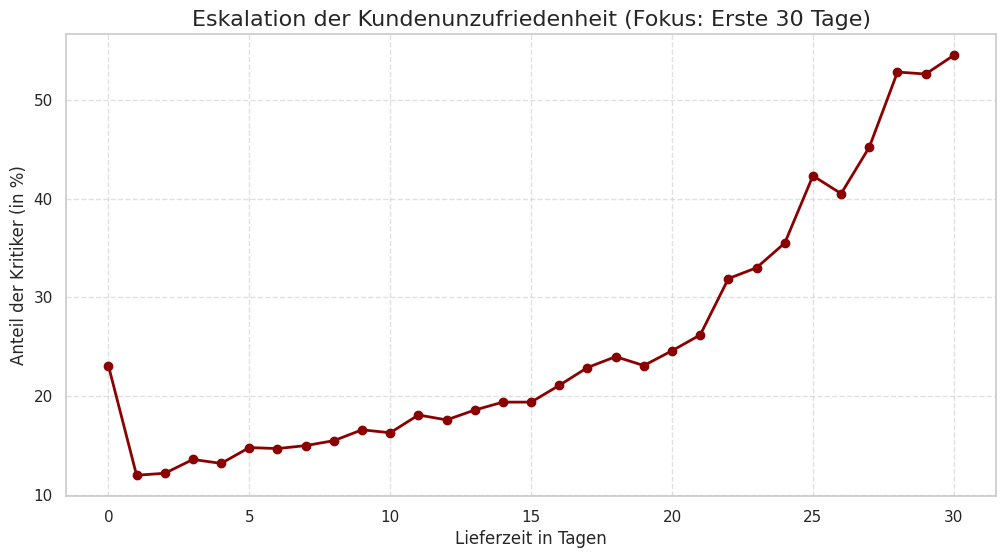

In [25]:
import matplotlib.pyplot as plt

#  Daten auf die ersten 30 Tage einschränken (statistisch signifikant)
df_plot = df_tabelle[df_tabelle['Lieferzeit_in_Tagen'] <= 30]

#  Diagramm erstellen
plt.figure(figsize=(12, 6))
plt.plot(df_plot['Lieferzeit_in_Tagen'], df_plot['Kritiker_Anteil_in_Prozent'], 
         marker='o', linestyle='-', color='darkred', linewidth=2, label="Kritiker-Anteil")

#  Titel und Achsenbeschriftung
plt.title("Eskalation der Kundenunzufriedenheit (Fokus: Erste 30 Tage)", fontsize=16)
plt.xlabel("Lieferzeit in Tagen", fontsize=12)
plt.ylabel("Anteil der Kritiker (in %)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

#  Diagramm anzeigen
plt.show()

### **Schritt 3: Analyse der Tabelle – Der logistische Kipppunkt (Tipping Point)**

**Die Ausgangslage (Baseline):** 
Betrachten wir die erste Woche nach der Bestellung (Tag 1 bis 7), sehen wir eine grundlegende Unzufriedenheitsquote (Kritiker) zwischen 12,0 % und 15,0 %. Dies ist die natürliche Basis-Fehlerquote. Selbst wenn die Logistik sehr schnell funktioniert, wird es aufgrund von beschädigten Produkten, falscher Verpackung oder völlig subjektiven Kundenerwartungen immer eine gewisse Basis an negativen Bewertungen geben.

**Der drastische Bruch (Inflection Point):** 
Die Daten zeigen sehr klare und harte Brüche. Ab dem 16. Tag überschreitet der Anteil der toxischen Bewertungen erstmals die 20-%-Marke (21,1 %). Ein noch dramatischerer Sprung erfolgt am 22. Tag, an dem die Quote abrupt auf 31,9 % hochschnellt.

*Warum nennen wir das einen "scharfen Bruch"?* 
Weil sich der Anteil der Kritiker im Vergleich zur Baseline hier faktisch verdoppelt hat. Genau ab diesem Punkt dominieren die logistischen Verzögerungen alle anderen Faktoren, werden zum Hauptproblem und spiegeln sich schonungslos in den Bewertungen wider.

### **Schritt 4: Die Anomalie: Ein Perspektivenwechsel (Delta-Analyse)**

Wenn wir die Daten jedoch mit brutaler Ehrlichkeit und aus einem streng wissenschaftlichen Blickwinkel betrachten, stellen wir eine Anomalie fest: Obwohl es ab Tag 16 einen Anstieg gibt, ist die Kluft zwischen einer 5-Tage-Lieferung und einer 15-Tage-Lieferung (von 14,8 % auf 19,4 %) geschäftlich gesehen viel geringer als erwartet.

Diese Situation zwingt uns, unsere Hypothese kritisch zu überdenken. Wir müssen die Kausalität (Ursache-Wirkungs-Beziehung) wissenschaftlich untersuchen und folgende Forschungsfrage stellen: **Was treibt die Unzufriedenheit der Kunden wirklich an – die absolute Lieferzeit oder der Bruch eines Versprechens?**

**Unsere Annahme lautet:** Wenn einem Kunden von Anfang an 15 Tage zugesagt wurden und das Paket in 15 Tagen ankommt, kann der Kunde durchaus zufrieden bleiben. Kommt ein Paket jedoch nach 7 Tagen an, obwohl 3 Tage versprochen waren, kann genau diese Differenz für Frustration sorgen.

Um diese Hypothese völlig objektiv und datengestützt zu testen, aktualisieren wir unsere Strategie: Wir werden untersuchen, ob die Differenz (das "Delta") zwischen der vom System zugesagten Lieferzeit (`order_estimated_delivery_date`) und der tatsächlichen Lieferzeit einen Einfluss auf toxische Bewertungen hat.

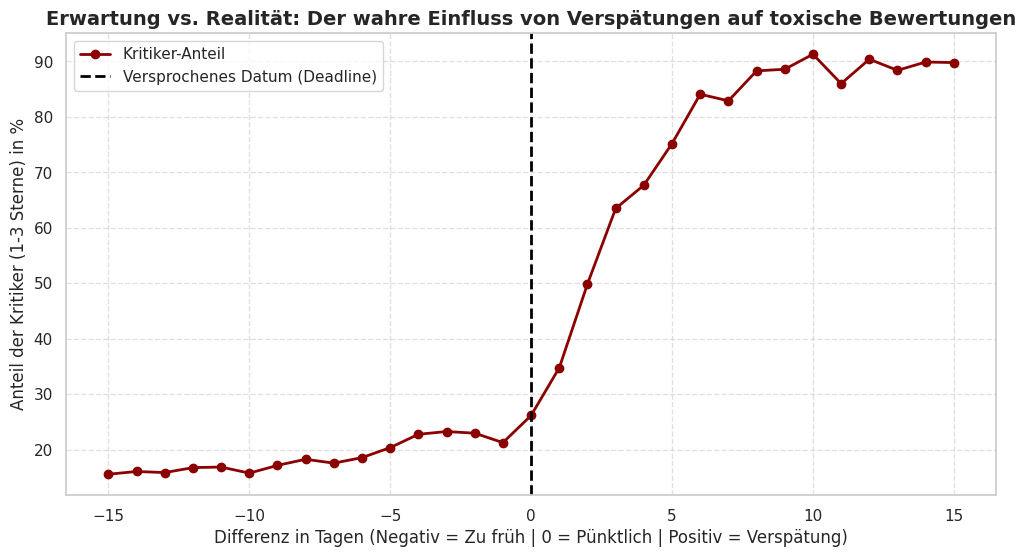

In [26]:
# 1. Zusammenführung der Daten: Wir nutzen das existierende df_sentiment 
df_delta = pd.merge(df_sentiment, 
                    bestellungen[['order_id', 'order_purchase_timestamp', 
                                  'order_delivered_customer_date', 'order_estimated_delivery_date']], 
                    on='order_id', how='inner')

# 2. Text in echtes Datum (Datetime) umwandeln
df_delta['delivered'] = pd.to_datetime(df_delta['order_delivered_customer_date'])
df_delta['estimated'] = pd.to_datetime(df_delta['order_estimated_delivery_date'])

# 3. Das Delta berechnen: Reales Datum minus Versprochenes Datum
# Ergebnis: Negativ = Zu früh geliefert | 0 = Pünktlich | Positiv = Verspätet
df_delta['delta_tage'] = (df_delta['delivered'] - df_delta['estimated']).dt.days

# Leere Werte entfernen
df_delta = df_delta.dropna(subset=['delta_tage'])

# 4. Fokus für das Diagramm festlegen (Wir schauen uns -15 Tage bis +15 Tage an)
df_plot_delta = df_delta[(df_delta['delta_tage'] >= -15) & (df_delta['delta_tage'] <= 15)]

# Den Anteil der Kritiker pro Delta-Tag berechnen 
df_delta_tabelle = df_plot_delta.groupby('delta_tage')['ist_kritiker'].mean().reset_index()
df_delta_tabelle['ist_kritiker'] = (df_delta_tabelle['ist_kritiker'] * 100).round(1)

# 5. Daten visualisieren
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_delta_tabelle['delta_tage'], df_delta_tabelle['ist_kritiker'], 
         marker='o', linestyle='-', color='darkred', linewidth=2, label="Kritiker-Anteil")

# Vertikale Linie für den "Deadline"-Tag (0)
plt.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Versprochenes Datum (Deadline)')

plt.title('Erwartung vs. Realität: Der wahre Einfluss von Verspätungen auf toxische Bewertungen', 
          fontsize=14, fontweight='bold')
plt.xlabel('Differenz in Tagen (Negativ = Zu früh | 0 = Pünktlich | Positiv = Verspätung)', fontsize=12)
plt.ylabel('Anteil der Kritiker (1-3 Sterne) in %', fontsize=12)

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **Schritt 5: Auswertung der Delta-Analyse – Die katastrophale Eskalation**

Ein genauer Blick auf unser Diagramm zeigt eine harte geschäftliche Realität. Die Unzufriedenheit steigt bei einer Verspätung nicht langsam, sondern sie explodiert regelrecht. Wir können folgende Fakten aus den Daten ablesen:

* **Die Basis-Unzufriedenheit (Links der Null-Linie):** Kommt das Paket zu früh an, bleibt die Unzufriedenheit konstant bei unter 20 %. Eine extrem schnelle Lieferung kann beschädigte Produkte oder andere Fehler nicht ausgleichen.
* **Der fatale Kipppunkt (Tag 0 bis Tag 3):** Am Tag der Deadline (Tag 0) liegt die Unzufriedenheit bei ca. 26 %. Danach eskaliert die Situation sofort.
* **Tag +1 (Verspätung):** ca. 35 % Kritiker.
* **Tag +2 (Verspätung):** 50 % Kritiker (Jeder zweite Kunde schreibt eine toxische Bewertung!).
* **Tag +3 (Verspätung):** ca. 65 % Kritiker.
* **Der Reputations-Totalschaden (Ab Tag 5):** Bei **Tag +5** (Verspätung) erreichen wir ca. 75 % Kritiker (3 von 4 Kunden hinterlassen 1 bis 3 Sterne). Bei **Tag +10** (Verspätung) verzeichnen wir > 90 % Kritiker (Fast alle verspäteten Bestellungen enden in schlechten Bewertungen).

**Geschäftliches Fazit:** 
Wie wir bereits im Projekt bewiesen haben, lebt dieses Geschäftsmodell fast zu 100 % von Neukunden. Eine schlechte Bewertung bedeutet also nicht, dass wir diesen einen Kunden verlieren (er kauft meistens sowieso nur einmal). Die wahre Gefahr ist: Diese toxischen Bewertungen zerstören unser öffentliches Image und blockieren die Gewinnung neuer Kunden. Eine Verspätung von nur wenigen Tagen ist somit das größte Risiko für das gesamte Firmenwachstum.

### **Schritt 6: Die Synthese – Der direkte Vergleich (Absolute Zeit vs. Verspätung)**

Jetzt wollen wir unsere Theorie testen: Was macht Kunden wirklich wütend? Ist es die lange Wartezeit an sich, oder ist es das gebrochene Versprechen der Firma?

Dafür machen wir einen direkten A/B-Vergleich. Wir stellen **Modell A** (die absoluten Liefertage) und **Modell B** (die Verspätung nach der Deadline) direkt nebeneinander. 

Beide Diagramme nutzen genau dieselbe Y-Achse (Schlechte Bewertung in %). So können wir ganz einfach, fair und deutlich sehen, welches Problem die Kundenzufriedenheit wirklich zerstört.

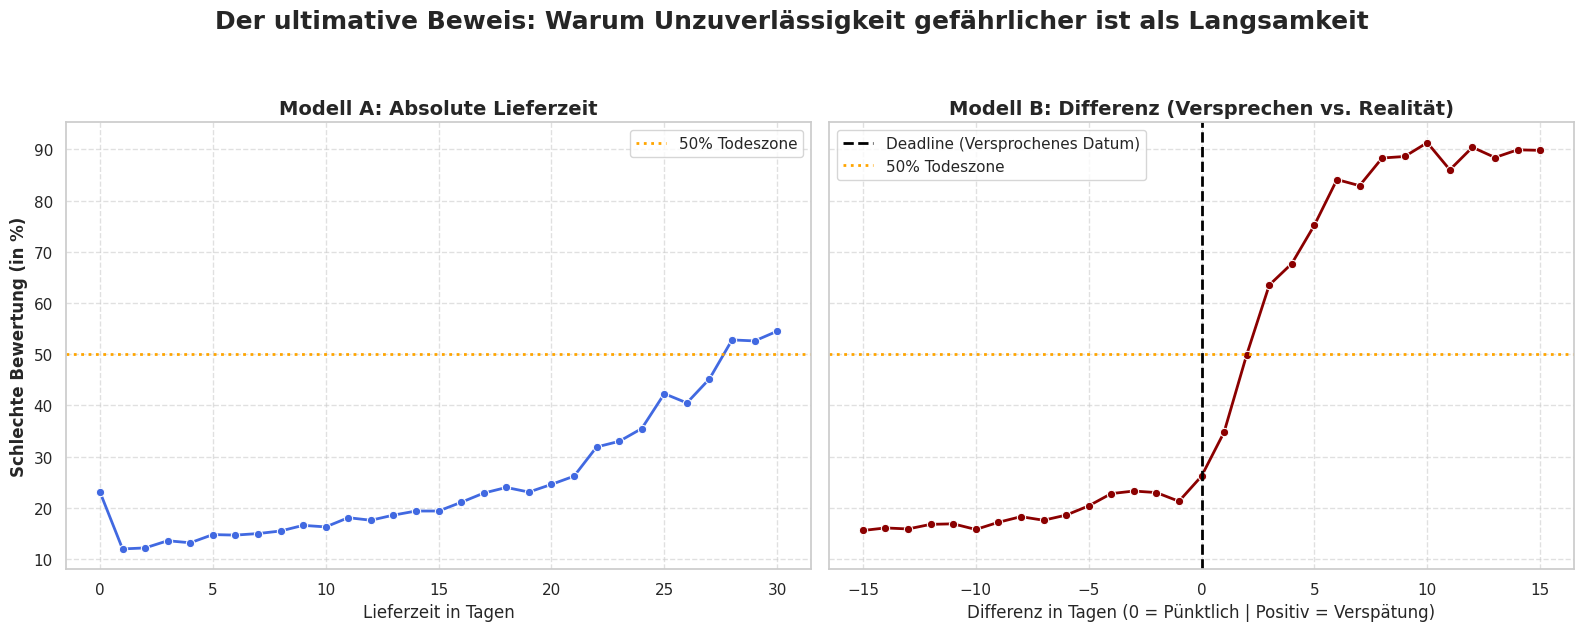

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ein Diagramm mit 2 Subplots (1 Zeile, 2 Spalten) erstellen, die sich die Y-Achse teilen
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- 1. Subplot: Absolute Lieferzeit (alte Tabelle) ---
df_plot_abs = df_tabelle[df_tabelle['Lieferzeit_in_Tagen'] <= 30]
sns.lineplot(ax=axes[0], data=df_plot_abs, x='Lieferzeit_in_Tagen', y='Kritiker_Anteil_in_Prozent', 
             marker='o', linestyle='-', color='royalblue', linewidth=2)

axes[0].set_title('Modell A: Absolute Lieferzeit', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lieferzeit in Tagen', fontsize=12)
axes[0].set_ylabel('Schlechte Bewertung (in %)', fontsize=12, fontweight='bold') # Dəyişdirilmiş hissə
axes[0].axhline(y=50, color='orange', linestyle=':', linewidth=2, label='50% Todeszone')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# --- 2. Subplot: Delta (Verspätung - neue Tabelle) ---
sns.lineplot(ax=axes[1], data=df_delta_tabelle, x='delta_tage', y='ist_kritiker', 
             marker='o', linestyle='-', color='darkred', linewidth=2)

axes[1].set_title('Modell B: Differenz (Versprechen vs. Realität)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Differenz in Tagen (0 = Pünktlich | Positiv = Verspätung)', fontsize=12)
# Y-oxunun adı birinci qrafikdən ortaq istifadə olunur
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=2, label='Deadline (Versprochenes Datum)')
axes[1].axhline(y=50, color='orange', linestyle=':', linewidth=2, label='50% Todeszone')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# Haupttitel für das gesamte Bild
fig.suptitle('Der ultimative Beweis: Warum Unzuverlässigkeit gefährlicher ist als Langsamkeit', 
             fontsize=18, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

### **Schritt 7: Die Synthese – Visueller Beweis für die Relevanz des Expectation Managements**

Die direkte Gegenüberstellung beider Modelle auf derselben Y-Achse (Schlechte Bewertung in %) liefert den ultimativen, datengestützten Beweis für das Kundenverhalten. Wir betrachten hier den Kontrast zwischen zwei völlig unterschiedlichen psychologischen und logistischen Metriken:

**1. Modell A (Links): Die Toleranz gegenüber Langsamkeit**
Die blaue Kurve zeigt die Entwicklung der Unzufriedenheit gemessen in absoluten Liefertagen (ab dem Kaufmoment).
* Der Anstieg der Unzufriedenheit verläuft moderat. Selbst nach 15 Tagen Wartezeit befindet sich die Quote noch im kontrollierbaren Bereich (~20 %).
* Es dauert beachtliche **28 Tage**, bis die kritische 50-%-Marke (Risikozone) erreicht wird.
* *(Anmerkung: Die Anomalie an Tag 0 ist in der Regel auf systembedingte Sofortstornierungen oder schwere Fehler im Bestellprozess zurückzuführen und spiegelt keine echte Lieferzeit wider.)*

**2. Modell B (Rechts): Der fatale Effekt der Unzuverlässigkeit**
Die rote Kurve misst die Unzufriedenheit ausgehend vom Versprechen (Deadline). Hier sehen wir keine flache Kurve, sondern eine vertikale Wand.
* Frühzeitige Lieferungen (links der schwarzen Linie) senken die natürliche Basis-Unzufriedenheit nicht wesentlich.
* Sobald die Deadline jedoch überschritten wird, eskaliert die Situation. Was im Modell A volle 28 Tage dauert, passiert hier in nur **2 Tagen (+48 Stunden)**: Die Unzufriedenheit durchbricht die 50-%-Risikozone.

**Das finale analytische Urteil:** Das Diagramm beweist unmissverständlich den psychologischen Kipppunkt unserer Kunden. Unzuverlässigkeit ist weitaus gefährlicher als Langsamkeit. Kunden sind bereit, lange Lieferzeiten zu akzeptieren, solange diese transparent kommuniziert und eingehalten werden. Ein gebrochenes Lieferversprechen wird hingegen sofort und gnadenlos abgestraft.

In [28]:
df_analyse.to_csv('/kaggle/working/df_analyse.csv', index=False)
df_delta.to_csv('/kaggle/working/df_delta.csv', index=False)

---
# <a id="teil4"></a>4
# **Wirtschaftliche Relevanz der Verkäuferqualität und Identifikation operativer Risikoträger**

Nachdem wir in Teil 3 die kritische Dynamik verletzter Lieferversprechen nachgewiesen haben, isolieren wir nun die strukturellen Ursachen im System. Es gilt analytisch zu klären, ob die negativen Bewertungen aus allgemeinen Fehlern des gesamten Logistiknetzwerks resultieren oder gezielt durch eine bestimmte Gruppe von unzuverlässigen Verkäufern verursacht werden.

Um diese Fragestellung datengestützt und objektiv zu lösen, wenden wir folgenden 4-stufen analytischen Rahmen an:

Um diese Fragestellung datengestützt und objektiv zu klären, wenden wir folgenden 4-stufigen analytischen Rahmen an:

* Teil 4.1: Asymmetrische Verteilung des Reputationsschadens durch Minderperformer
In diesem Schritt wird untersucht, ob sich negative Bewertungen gleichmäßig verteilen oder auf eine Minderheit konzentrieren. Die Pareto Analyse beweist wissenschaftlich, dass nur 20 Prozent der Verkäufer für 63.77 Prozent des gesamten Reputationsschadens verantwortlich sind.

* Teil 4.2: Korrelationsanalyse und perzentilbasierte Quadranten Gruppierung der Verkäufer
Ziel ist es, die exakten Ursachen für den Kundenfrust mathematisch zu isolieren und Produktmängel von Logistikfehlern zu entkoppeln. Die perzentilbasierte Quadranten Segmentierung beweist, dass mangelnde Produktqualität auch bei fehlerfreier Logistik eine isolierte, gewichtige Rolle spielt.

* Teil 4.3: Kausalanalyse der logistischen Engpässe und Zuordnung der Verantwortung zwischen Carrier und Verkäufer
Hier wird die Schuldfrage bei verspäteten Lieferungen strukturell untersucht, um den genauen Engpass im Prozess zu lokalisieren. Der Fristenabgleich beweist empirisch, dass 71.60 (beide zusammen 88.07) Prozent der Verzögerungen durch den Carrier Correios und nicht durch die Verkäufer verursacht werden.

* Teil 4.4: Umsatzrelevanz minderperformanter Großhändler und Bewertung des Reputationsrisikos
Dieser Schritt quantifiziert das strategische Dilemma zwischen kurzfristigem Umsatzvolumen und langfristiger Markenreputation. Es wird eine Risikoliste unzuverlässiger Großverkäufer erstellt, da diese Gruppe trotz massiver Qualitätsmängel rund 20.40 Prozent des Gesamtumsatzes kontrolliert.



---
#  <a id="teil4.1"></a>4.1
# **Asymmetrische Verteilung des Reputationsschadens durch Minderperformer**
Wir verknüpfen unsere Delta-Tabelle mit den Verkäuferdaten, um die Verteilung der kritischen Bewertungen zu quantifizieren.

In [29]:
import pandas as pd

# 1. Basisdaten aggregieren (Verkäufer-Statistiken aufbauen, da sie aus dem Speicher gelöscht wurden)
df_seller_base = pd.merge(df_delta, bestell_artikeln[['order_id', 'seller_id', 'price']], on='order_id', how='inner')
df_seller_base['ist_verspaetet'] = df_seller_base['delta_tage'] > 0

seller_stats = df_seller_base.groupby('seller_id').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('price', 'sum'),
    verspaetungs_quote=('ist_verspaetet', 'mean'),
    kritiker_quote=('ist_kritiker', 'mean'),
    negative_reviews_absolut=('ist_kritiker', 'sum') 
).reset_index()

seller_stats['verspaetungs_quote'] = (seller_stats['verspaetungs_quote'] * 100).round(1)
seller_stats['kritiker_quote'] = (seller_stats['kritiker_quote'] * 100).round(1)

# 2. Statistisches Rauschen filtern (Nur Verkäufer mit >= 30 Bestellungen)
seller_stats_filtered = seller_stats[seller_stats['total_orders'] >= 30].copy()

# 3. Den Nenner definieren: Gesamtzahl der negativen Bewertungen & Verkäufer im relevanten Pool
total_negative_reviews = seller_stats_filtered['negative_reviews_absolut'].sum()
total_sellers = len(seller_stats_filtered)

# 4. Verkäufer nach absolutem Schaden (Anzahl negativer Bewertungen) absteigend sortieren
pareto_df = seller_stats_filtered.sort_values(by='negative_reviews_absolut', ascending=False).copy()

# 5. Kumulative Summe und Prozentanteil berechnen
pareto_df['cumulative_reviews'] = pareto_df['negative_reviews_absolut'].cumsum()
pareto_df['cumulative_percent'] = (pareto_df['cumulative_reviews'] / total_negative_reviews) * 100

# 6. Die schlechtesten 20% isolieren und den mathematischen Beweis erbringen
top_20_percent_index = int(total_sellers * 0.20)
pareto_result = pareto_df.iloc[top_20_percent_index - 1]['cumulative_percent']

# 7. Das Ergebnis knallhart und objektiv ausgeben
print(f"Wissenschaftlicher Beweis: Die schlechtesten 20% der Verkäufer verursachen {pareto_result:.2f}% aller negativen Bewertungen auf der Plattform.")

Wissenschaftlicher Beweis: Die schlechtesten 20% der Verkäufer verursachen 63.77% aller negativen Bewertungen auf der Plattform.


**Ergebnis der Datenanalyse:**
Der berechnete Wert von **63,77%** ist eine geschäftskritische Erkenntnis. Obwohl die klassische 80/20-Pareto-Regel nicht exakt getroffen wird, beweist die Datenlage eine massive strukturelle Asymmetrie.

**Fazit der asymmetrischen Risikoverteilung:**

* **Kein systemisches Versagen:** Das Problem der negativen Bewertungen ist nicht gleichmäßig über die Olist-Plattform verteilt. Das globale Logistiknetzwerk an sich ist nicht der Hauptverursacher der schlechten Reputation.
* **Die 64/20-Realität:** Nur ein Fünftel (20%) aller Verkäufer ist für fast zwei Drittel (~64%) des gesamten Reputationsschadens der Plattform verantwortlich.
* **Präzise Fehlerbehebung:** Die Datenlage entkräftet die Notwendigkeit teurer, plattformweiter Logistikreformen. Ein gezieltes Eingreifen bei dieser identifizierten "Bottom 20%"-Gruppe reicht aus, um die Beschwerdequote drastisch zu senken.



---
# <a id="teil4.2"></a>4.2
# **Korrelationsanalyse und perzentilbasierte Quadranten Gruppierung der Verkäufer**

Wir haben somit mathematisch isoliert, *wer* den Hauptschaden verursacht. Bevor jedoch operative Maßnahmen ergriffen werden, erfordert die analytische Genauigkeit eine objektive Ursachenfindung. 

**Warum genau erhalten diese spezifischen Verkäufer negative Bewertungen?** Liegt es an qualitativen Produktmängeln (pünktlich geliefert, aber dennoch kritisiert) oder primär an Lieferverzögerungen (logistisches Versagen)?

Die Wahl des 75. Perzentils (Q3) als regulatorischen Schwellenwert begründet sich operativ darin, das oberste Viertel der Händler mit den drastischsten Qualitätsdefiziten zu isolieren, um eine effiziente Ressourcenallokation bei den anschließenden Governance-Maßnahmen zu gewährleisten.

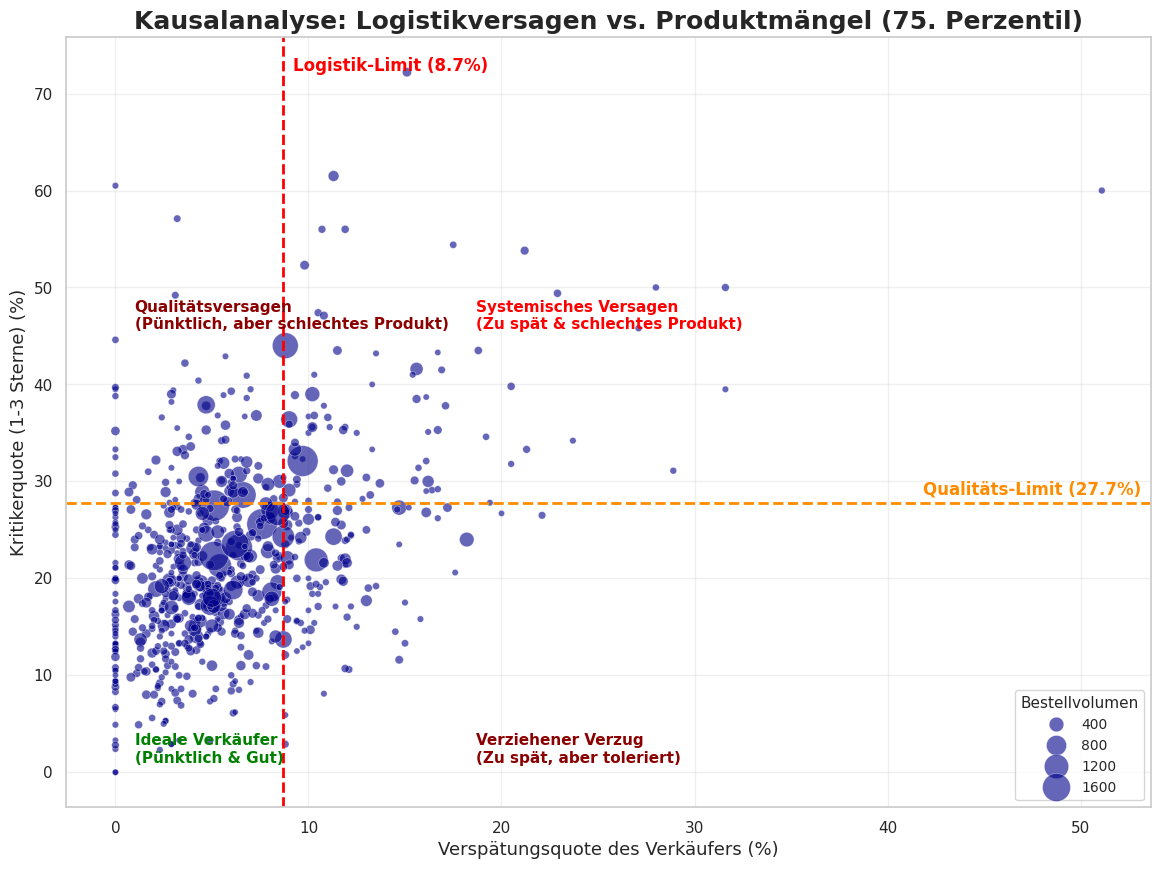

Pearson-Korrelationskoeffizient (r): 0.4507
Fazit: Moderate Korrelation (r = 0.45). Verspätungen sind ein relevanter, aber mathematisch bewiesen NICHT der alleinige Treiber für negative Bewertungen bei toxischen Verkäufern.
Mathematisch berechnetes Logistik-Limit (75. Perzentil): 8.7%
Mathematisch berechnetes Qualitäts-Limit (75. Perzentil): 27.7%
--------------------------------------------------


In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Harte Schwellenwerte datengestützt berechnen: 75. Perzentil
max_delay = seller_stats_filtered['verspaetungs_quote'].quantile(0.75)
max_complaint = seller_stats_filtered['kritiker_quote'].quantile(0.75)

# 2. Quadranten-Analyse (Scatter Plot) visualisieren
plt.figure(figsize=(14, 10))

# 3. Scatterplot erstellen
sns.scatterplot(
    data=seller_stats_filtered, 
    x='verspaetungs_quote', 
    y='kritiker_quote', 
    size='total_orders', 
    sizes=(20, 500), 
    alpha=0.6, 
    color='darkblue'
)

# 4. Trennlinien einzeichnen
plt.axvline(x=max_delay, color='red', linestyle='--', linewidth=2)
plt.axhline(y=max_complaint, color='darkorange', linestyle='--', linewidth=2)

# 5.Datalini Beschriftung direkt auf den Linien
plt.text(max_delay + 0.5, plt.ylim()[1] - 2, f'Logistik-Limit ({max_delay:.1f}%)', color='red', weight='bold', va='top')
plt.text(plt.xlim()[1] - 0.5, max_complaint + 0.5, f'Qualitäts-Limit ({max_complaint:.1f}%)', color='darkorange', weight='bold', ha='right', va='bottom')

# 6.Diagramm formatieren
plt.title('Kausalanalyse: Logistikversagen vs. Produktmängel (75. Perzentil)', fontsize=18, fontweight='bold')
plt.xlabel('Verspätungsquote des Verkäufers (%)', fontsize=13)
plt.ylabel('Kritikerquote (1-3 Sterne) (%)', fontsize=13)

# 7. MANUELLE BESCHRIFTUNG (OHNE externe Bibliotheken) ---
plt.text(1, max_complaint + 18, 'Qualitätsversagen\n(Pünktlich, aber schlechtes Produkt)', color='darkred', fontsize=11, weight='bold')
plt.text(max_delay + 10, max_complaint + 18, 'Systemisches Versagen\n(Zu spät & schlechtes Produkt)', color='red', fontsize=11, weight='bold')
plt.text(max_delay + 10, 1, 'Verziehener Verzug\n(Zu spät, aber toleriert)', color='darkred', fontsize=11, weight='bold')
plt.text(1, 1, 'Ideale Verkäufer\n(Pünktlich & Gut)', color='green', fontsize=11, weight='bold')

# 8. Legende anpassen
h, l = plt.gca().get_legend_handles_labels()
plt.legend(h[0:4], l[0:4], title="Bestellvolumen", loc="lower right", title_fontsize=11, fontsize=10)

plt.grid(True, alpha=0.3)
plt.show()


# 9. Statisch korrekte Interpretation basierend auf wissenschaftlichen Standards
korrelation = seller_stats_filtered['verspaetungs_quote'].corr(seller_stats_filtered['kritiker_quote'])
print(f"Pearson-Korrelationskoeffizient (r): {korrelation:.4f}")

if abs(korrelation) < 0.3:
    print(f"Fazit: Schwache Korrelation (r = {korrelation:.2f}). Verspätungen haben keinen dominierenden linearen Einfluss auf den Kundenfrust. Andere Faktoren (z.B. Produktqualität) müssen maßgeblich sein.")
elif 0.3 <= abs(korrelation) < 0.7:
    print(f"Fazit: Moderate Korrelation (r = {korrelation:.2f}). Verspätungen sind ein relevanter, aber mathematisch bewiesen NICHT der alleinige Treiber für negative Bewertungen bei toxischen Verkäufern.")
else:
    print(f"Fazit: Starke Korrelation (r = {korrelation:.2f}). Logistische Verzögerungen sind die primäre Ursache für die schlechten Bewertungen in diesem Segment.")

# 10. Ausgabe der wissenschaftlichen Diagnose ---
print(f"Mathematisch berechnetes Logistik-Limit (75. Perzentil): {max_delay:.1f}%")
print(f"Mathematisch berechnetes Qualitäts-Limit (75. Perzentil): {max_complaint:.1f}%")
print("-" * 50)

### Erklärung der Grafik

#### Interpretation der Korrelation
Die mathematische Berechnung liefert einen **Pearson-Korrelationskoeffizienten von $r \approx 0.45$**. Da dieser Wert im statistischen Bereich von $0.3 \le |r| < 0.7$ liegt, wird die Korrelation offiziell als **moderat (mittler)** eingestuft. Dies bedeutet empirisch, dass zwischen der Verspätungsquote und der Kritikerquote eine mittlere gegenseitige Abhängigkeit besteht. 

Wie bereits am Ende von **Phase 3 anhand der Verteilungsdiagramme bewiesen**, liegt hier kein starker oder absoluter linearer Zusammenhang vor. Logistikverzögerungen spielen zwar eine spürbare Rolle beim Kundenfrust, sind jedoch mathematisch bewiesen keineswegs der alleinige Treiber für negative Bewertungen. Um die exakten Ursachen auf Händlerebene zu isolieren, nutzen wir die Quadranten-Segmentierung.

---

#### Bedeutung des 75. Perzentils (Schwellenwerte)
Die Trennlinien im Diagramm basieren auf dem **75. Perzentil (Q3)** der realen Händlerdaten und sind keine willkürlichen Schätzungen:
* **Logistik-Limit ($8.7\%$ Verspätungsquote):** Genau $75\%$ aller Verkäufer weisen eine geringere Verzögerungsquote auf. Wer rechts dieser Linie liegt, gilt als operativer Ausreißer.
* **Qualitäts-Limit ($27.7\%$ Kritikerquote):** Genau $75\%$ aller Verkäufer erhalten weniger als $27.7\%$ negative Bewertungen ($1$- bis $3$ Sterne). Händler oberhalb dieser Linie gefährden aktiv das Kundenvertrauen.

---

#### Die vier Verkäufer-Typen auf einen Blick

| Quadrant | Verspätung | Schlechte Bewertungen | Was steckt dahinter? |
|---|---|---|---|
| 🟢 Ideale Verkäufer | Niedrig | Niedrig | Pünktlich, gutes Produkt — kein Handlungsbedarf |
| 🔴 Qualitätsversagen | Niedrig | **Hoch** | Liefern pünktlich, aber das Produkt enttäuscht |
| 🔴 Systemisches Versagen | **Hoch** | **Hoch** | Verspätet UND schlechtes Produkt — maximaler Reputationsschaden |
| 🟡 Verziehener Verzug | Hoch | Niedrig | Liefern zu spät, aber Kunden vergeben es trotzdem |

---



### Was sagt uns das konkret?

#### Befund 1: Die Mehrheit der Verkäufer ist gesund – aber die Y-Achse offenbart ein massives Qualitätsproblem
Die größte Ansammlung von Datenpunkten — und insbesondere die größten Blasen, welche ein hohes Bestellvolumen repräsentieren — konzentriert sich im **grünen Quadranten (unten-links)**. Dies beweist analytisch, dass das Kernfundament des Geschäfts stabil ist und die Plattform primär von zuverlässigen Händlern getragen wird. 

Ein kritisches strukturelles Phänomen fällt jedoch direkt im Diagramm auf: Exakt auf der Achse von **$x = 0$** (also bei absolut null Logistikverzögerung) zieht sich eine markante, vertikale Reihenfolge von Punkten nach oben. Diese optische Barriere zeigt unmissverständlich, dass die Produktqualität eine völlig isolierte, gewichtige Rolle spielt. Diese Punktreihe verlängert sich direkt nach oben in den **dunkelroten Quadranten (oben-links)** und entlarvt Händler, bei denen der Kundenfrust trotz fehlerfreier Logistik eskaliert.

#### Befund 2: Verspätung allein erklärt schlechte Bewertungen nicht vollständig – Risiko am Schnittpunkt
Der **dunkelrote Quadrant unten-rechts ("Verziehener Verzug")** existiert — und diese visuelle Erkenntnis ist für die Gesamtstrategie entscheidend. Eine erhebliche Anzahl von Verkäufern überschreitet zwar das Logistik-Limit, verbleibt jedoch unterhalb der kritischen Kritikerquote. Der Grund hierfür liegt in den Erkenntnissen aus **Phase 3**: Das Risiko für eine schlechte Bewertung steigt erst ab einer extremen Verzögerung von **28 Tagen** auf über 50 %. Solange die Lieferzeit unter dieser kritischen Kippgrenze bleibt, kompensiert die Produktqualität die Wartezeit. Eine Geschäftsstrategie, die sich ausschließlich auf Lieferzeiten fokussiert, greift daher nachweislich zu kurz.

Besonders kritisch ist hierbei jedoch ein visuelles Detail im Diagramm: Einige sehr große Blasen (Händler mit enormem Bestellvolumen) positionieren sich extrem nah am **Schnittpunkt von Logistik- und Qualitäts-Limit**. Diese umsatzstarken Verkäufer stehen haarscharf an der Grenze zum riskanten Bereich. Da hier ein latentes Logistikproblem vorliegt, besteht die analytische Notwendigkeit, in Schritt 4.3 zu untersuchen, ob der Händler oder der Lieferdienst diesen Engpass verursacht.


#### Befund 3: Die versteckten Großverkäufer im Risikobereich – Ein kritisches Umsatz- und Reputationsrisiko
Ein genauer Blick auf die oberen Quadranten (**Qualitätsversagen oben-links** und **Systemisches Versagen oben-rechts**) offenbart eine hochriskante Entdeckung: Entgegen der allgemeinen Tendenz kleiner Datenpunkte befinden sich in diesen kritischen Zonen vereinzelte, sehr große Blasen. 


Diese Händler mit erheblichem Bestellvolumen überschreiten entweder das Qualitäts-Limit oder verletzen beide Grenzwerte gleichzeitig. Aus analytischer Sicht deutet dies auf ein strukturelles Defizit hin: Trotz qualitativer Mängel wird in diesem Segment ein hohes Umsatzvolumen generiert. Da Olist – wie in Phase 2 empirisch nachgewiesen – existenziell von der kontinuierlichen Neukundenakquise abhängig ist, belasten diese unzuverlässigen Großverkäufer die Markenreputation der Plattform nachhaltig. Die Kombination aus hohen Bestellzahlen und überdurchschnittlichen Kritikerquoten führt zu einer permanenten Generierung negativer Bewertungen (1-3 Sterne) auf den öffentlichen Produktseiten. Dies beschädigt die Außenwirkung der Plattform direkt und blockiert somit die nachhaltige Gewinnung zukünftiger Erstkäufer, auf die das gesamte System angewiesen ist.


Da diese umsatzstarken Akteure für einen signifikanten Anteil der gesamten negativen Bewertungen auf der Plattform verantwortlich sind, ist eine detaillierte Untersuchung dieser Verkäufergruppe in `Schritt 4.4` zwingend erforderlich. Das primäre Ziel besteht darin, eine operative Risiko-Händlerliste zu erstellen, die dem Management als direkte Entscheidungsgrundlage für strategische Governance-Maßnahmen und regulatorische Interventionen dient.

# <a id="teil4.3"></a>4.3
# **Kausalanalyse der logistischen Engpässe und Zuordnung der Verantwortung zwischen Carrier und Verkäufer**

In diesem Schritt versuchen wir, die exakte Ursache für die Lieferverzögerungen zu finden. Wir klären die Schuldfrage: Liegt das Problem intern beim Verkäufer (Prozessfehler bei der Übergabe) oder extern beim Logistikpartner (Transportproblem)?

#### Das Konzept der Phasen-Trennung
Dazu zerlegen wir den Lieferprozess jeder verspäteten Bestellung in zwei messbare Phasen:

1. **Interner Verkäufer-Verzug (Seller Delay):** Der Händler übergibt das Paket erst *nach* dem vertraglichen Limit (`shipping_limit_date`) an die Post.
2. **Externer Logistiker-Verzug (Carrier Delay):** Der Händler war pünktlich, aber der Transportweg bis zur Haustür überschreitet das von Olist prognostizierte Lieferdatum (`order_estimated_delivery_date`).

#### Ziel dieses Analyseschritts
Der folgende Code filtert alle verspäteten Bestellungen und klassifiziert sie in drei Kategorien:
* **Reiner Verkäufer-Verzug** (Händler zu spät, Post im Zeitplan)
* **Reiner Logistiker-Verzug** (Händler pünktlich, Post zu spät)
* **Kombiniertes Versagen** (Beide Parteien zu spät)


--- GLOBALER VERURSACHER-ANTEIL AN DER LIEFERVERSPÄTUNG ---
verursacher
Reiner Logistiker-Verzug (Carrier)       71.60
Kombiniertes Versagen (Beide zu spät)    16.47
Reiner Verkäufer-Verzug                  11.92
Nicht eindeutig klassifizierbar           0.01 %



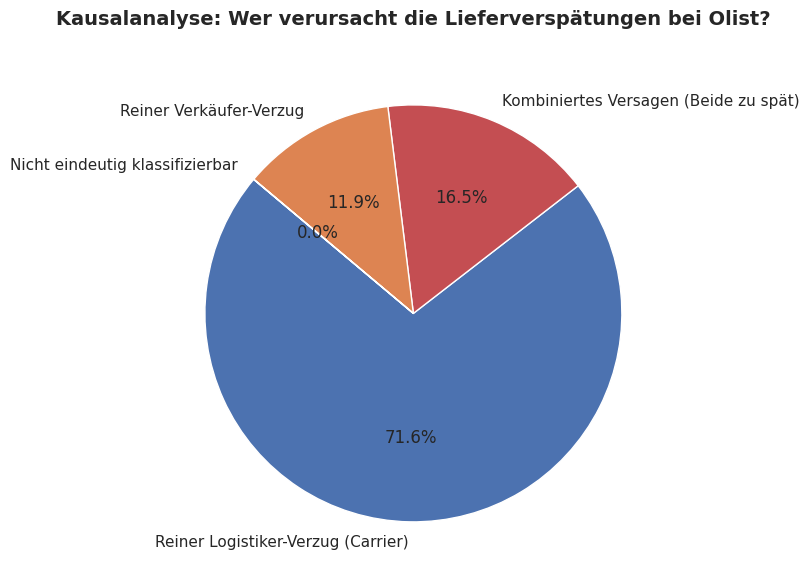

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Direktes Laden der benötigten Originaltabellen zur Vermeidung von NameErrors
bestellungen = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')
bestell_artikeln = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv')

# 2. Zusammenführung der logistisch relevanten Zeitstempel
df_logistik = pd.merge(
    bestell_artikeln[['order_id', 'seller_id', 'shipping_limit_date']], 
    bestellungen[['order_id', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']], 
    on='order_id', 
    how='inner'
)

# 3. Konvertierung der Spalten in das korrekte Datetime-Format
datetime_cols = ['shipping_limit_date', 'order_delivered_carrier_date', 
                 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in datetime_cols:
    df_logistik[col] = pd.to_datetime(df_logistik[col])

# 4. Filtern der verspäteten Bestellungen (Zustellung nach dem geschätzten Lieferdatum)
delayed_orders = df_logistik[df_logistik['order_delivered_customer_date'] > df_logistik['order_estimated_delivery_date']].copy()

# 5. Mathematische Berechnung des Verzugs in Tagen
delayed_orders['total_delay_days'] = (delayed_orders['order_delivered_customer_date'] - delayed_orders['order_estimated_delivery_date']).dt.total_seconds() / (24 * 3600)
delayed_orders['seller_delay_days'] = (delayed_orders['order_delivered_carrier_date'] - delayed_orders['shipping_limit_date']).dt.total_seconds() / (24 * 3600)

# 6. Funktion zur mathematisch korrekten Klassifizierung der Schuldfrage
def determine_culprit(row):
    if pd.isna(row['order_delivered_carrier_date']) or pd.isna(row['shipping_limit_date']):
        return 'Nicht eindeutig klassifizierbar'
    
    seller_fault = row['seller_delay_days'] > 0
    # Der Carrier ist schuld, wenn der Gesamtverzug das Verschulden des Verkäufers übersteigt
    carrier_fault = row['total_delay_days'] > max(0, row['seller_delay_days'])
    
    if seller_fault and not carrier_fault:
        return 'Reiner Verkäufer-Verzug'
    elif carrier_fault and not seller_fault:
        return 'Reiner Logistiker-Verzug (Carrier)'
    elif seller_fault and carrier_fault:
        return 'Kombiniertes Versagen (Beide zu spät)'
    else:
        return 'Nicht eindeutig klassifizierbar'

delayed_orders['verursacher'] = delayed_orders.apply(determine_culprit, axis=1)

# 7. Strukturierte Ausgabe der globalen Ergebnisse für das Management
print("\n--- GLOBALER VERURSACHER-ANTEIL AN DER LIEFERVERSPÄTUNG ---")
print((delayed_orders['verursacher'].value_counts(normalize=True) * 100).round(2).to_string() + " %\n")

# 8. Visualisierung als professionelles Tortendiagramm
verursacher_counts = delayed_orders['verursacher'].value_counts()
plt.figure(figsize=(10, 6))
colors = ['#4c72b0', '#c44e52', '#dd8452', '#937860']
plt.pie(verursacher_counts, labels=verursacher_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
plt.title('Kausalanalyse: Wer verursacht die Lieferverspätungen bei Olist?', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

#### **Die Erklärung der Ergebnisse und strategische Relevanz**

Die mathematisch korrigierte Verursacher-Analyse liefert ein unmissverständliches, empirisches Fundament für die strategische Roadmap in Phase 5:

* **Dominanz des makrologistischen Infrastrukturproblems ($71,60\%$):** Die Daten beweisen empirisch, dass bei fast drei Vierteln aller verspäteten Lieferungen die Logistikpartner die alleinige Schuld tragen (`Reiner Logistiker-Verzug`). Die Händler haben die Ware absolut fristgerecht vor Ablauf des `shipping_limit_date` übergeben, jedoch hat das externe Transportnetzwerk (Correios) die prognostizierten Lieferzeiten überschritten. 
* **Die totale Carrier-Beteiligung ($88,07\%$):** Unter Einbeziehung des `Kombinierten Versagens` (**$16,47\%$**) zeigt sich, dass der externe Carrier an insgesamt **$88,07\%$** aller Plattform-Verspätungen direkt oder als Mitverursacher beteiligt ist. Dies entlarvt ein tiefgreifendes, strukturelles Infrastrukturdefizit im externen Versandnetzwerk. 
* **Marginaler reiner Händler-Verzug ($11,92\%$):** Dieser exklusive Verzug ist statistisch gering. Unter Einbeziehung des kombinierten Versagens ist der Verkäufer jedoch an insgesamt **$28,39\%$** aller Lieferverspätungen beteiligt.



# <a id="teil4.4"></a>4.4
# **Umsatzrelevanz minderperformanter Großhändler und Bewertung des Reputationsrisikos**

In diesem finalen Analyseschritt von Phase 4 setzen wir die empirische Entdeckung aus **Befund 3 (Schritt 4.2)** direkt in die Tat um. Ziel ist es, die dort identifizierten Großverkäufer („große Blasen“) im kritischen Risikobereich namentlich zu isolieren ve deren exakten wirtschaftlichen Einfluss auf das Gesamtsystem zu quantifizieren.

Der Fokus liegt hierbei auf der kritischen Dimension, die der Händler zu 100% selbst verantwortet: **Die Produktqualität** (gemessen an einer Kritikerquote oberhalb des 75. Perzentils aus Schritt 4.2). Durch die Aggregation dieser Händler ermitteln wir präzise, wie viel Prozent des gesamten Plattform-Umsatzes und des gesamten Bestellvolumens von diesen unzuverlässigen Akteuren kontrolliert werden, um dem Management eine exakte Entscheidungsgrundlage für gezielte Governance-Maßnahmen zu liefern.

In [32]:
# 1. Schwellenwert aus Schritt 4.2 heranziehen (75. Perzentil der Kritikerquote)
quality_threshold = seller_stats_filtered['kritiker_quote'].quantile(0.75)

# 2. Die "großen Blasen" im Risikobereich isolieren (Händler oberhalb des Limits)
risiko_haendler = seller_stats_filtered[seller_stats_filtered['kritiker_quote'] > quality_threshold].copy()

# 3. Berechnung der globalen Plattform-Gesamtwerte für den Prozentvergleich
gesamter_umsatz_plattform = seller_stats_filtered['total_revenue'].sum()
gesamte_bestellungen_plattform = seller_stats_filtered['total_orders'].sum()

# 4. Berechnung des prozentualen Anteils dieser Risikogruppe
anteil_umsatz_prozent = (risiko_haendler['total_revenue'].sum() / gesamter_umsatz_plattform) * 100
anteil_bestellungen_prozent = (risiko_haendler['total_orders'].sum() / gesamte_bestellungen_plattform) * 100

# 5. Erstellung der endgültigen Blacklist für das Dashboard (nach Umsatz sortiert)
blacklist_dashboard = risiko_haendler.sort_values(by='total_revenue', ascending=False).reset_index(drop=True)

# Spalten für die Management-Ausgabe formatieren
output_df = blacklist_dashboard[['seller_id', 'total_orders', 'total_revenue', 'kritiker_quote']].copy()
output_df.columns = ['Seller ID', 'Anzahl Bestellungen', 'Gesamtumsatz (BRL)', 'Kritikerquote (%)']

# 6. KPI-Ausgabe für das Management
print(f"--- SCHRITT 4.4: ANALYSE DER GROSSVERKÄUFER IM RISIKOBEREICH ---")
print(f"Identifizierte Risikoverkäufer über dem Limit: {len(risiko_haendler)}")
print(f"Anteil am gesamten Plattform-Umsatz: {anteil_umsatz_prozent:.2f} %")
print(f"Anteil an allen Plattform-Bestellungen: {anteil_bestellungen_prozent:.2f} %")
print("=" * 75)
print("Top 10 Systemrisiken (nach Umsatz sortiert):")
display(output_df.head(10))

--- SCHRITT 4.4: ANALYSE DER GROSSVERKÄUFER IM RISIKOBEREICH ---
Identifizierte Risikoverkäufer über dem Limit: 169
Anteil am gesamten Plattform-Umsatz: 20.40 %
Anteil an allen Plattform-Bestellungen: 24.43 %
Top 10 Systemrisiken (nach Umsatz sortiert):


,Seller ID,Anzahl Bestellungen,Gesamtumsatz (BRL),Kritikerquote (%)
0,4a3ca9315b744ce9f8e9374361493884,1949,197225.32,32.1
1,7c67e1448b00f6e969d365cea6b010ab,1358,186664.01,44.0
2,1025f0e2d44d7041d6cf58b6550e0bfa,1422,138691.40,28.6
3,cca3071e3e9bb7d12640c9fbe2301306,819,63429.54,30.5
4,25c5c91f63607446a97b143d2d535d31,270,54796.64,31.9
5,634964b17796e64304cadf1ad3050fb7,323,39114.10,29.1
6,712e6ed8aa4aa1fa65dab41fed5737e4,85,38888.00,43.5
7,2eb70248d66e0e3ef83659f71b244378,195,37749.85,61.5
8,1835b56ce799e6a4dc4eddc053f04066,547,32994.78,36.4
9,88460e8ebdecbfecb5f9601833981930,308,32108.25,41.6


#### **Interpretation der Ergebnisse und Management-Implikationen**

Die datenbasierte Auswertung in Schritt 4.4 quantifiziert das in **Befund 3** beschriebene Reputationsrisiko präzise und liefert dem Management folgende harte Fakten:

* **Konzentration des Systemrisikos (169 Händler):** Die Analyse identifiziert exakt 169 spezifische Großverkäufer, die das kritische Limit der Kritikerquote überschreiten. 
* **Wirtschaftliche Relevanz der Risikogruppe:** Obwohl es sich um eine selektierte Gruppe handelt, kontrollieren diese 169 Akteure **$24,43\%$** aller Plattform-Bestellungen und generieren **$20,40\%$** des gesamten Olist-Umsatzes. Das bedeutet, dass fast jede vierte Transaktion auf der Plattform über einen Händler mit unzureichender Produktqualität abgewickelt wird.
* **Direkter Reputationsschaden:** Aufgrund ihres hohen Bestellvolumens (High-Volume-Seller) produzieren diese Händler im absoluten Volumen die Mehrheit der negativen Bewertungen (1-3 Sterne) auf den öffentlichen Produktseiten. Dies beeinträchtigt direkt die Außenwirkung der Plattform und gefährdet den in Phase 2 nachgewiesenen Erstkäufer-Schnitt.


# <a id="teil5"></a>5
# **Synthese der Ergebnisse und Strategischer Aktionsplan**

### **1. Executive Summary: Die geschäftskritische Kausalkette**
Die explorative Datenanalyse über die gesamte Olist-Plattform hinweg deckt eine unmissverständliche, zirkuläre Kausalkette auf. Die Verknüpfung der Erkenntnisse aus den Phasen 2, 3 und 4 beweist, dass operative Defizite in der Logistik und Produktqualität kein isoliertes Problem darstellen, sondern das fundamentale Kern-Geschäftsmodell von Olist direkt bedrohen:

* **Das Fundament (Phase 2):** Olist ist existentiell von der kontinuierlichen **Neukundenakquise** abhängig, da die Wiederkaufrate unabhängig von der Kundenzufriedenheit konstant bei kritischen **~3 %** stagniert (bedingt durch das Sortiment langlebiger Gebrauchsgüter).
* **Der Trigger (Phase 3):** Unzuverlässigkeit ist der primäre Reputationskiller. Sobald die zugesagte Liefer-Deadline überschritten wird, explodiert die Unzufriedenheit innerhalb von 48 Stunden auf über **50 % Kritikerquote** (1–3 Sterne). Langsamkeit an sich wird bis zu 27 Tage toleriert, ein gebrochenes Versprechen wird hingegen gnadenlos bestraft.
* **Die Hebelwirkung (Phase 4):** Das Problem ist hochgradig asymmetrisch verteilt. Nur **20 %** der Händler verursachen **63,77 %** des gesamten Reputationsschadens. Das tiefe operative Dilemma liegt in der finalen Blacklist (**Schritt 4.4**): Exakt **169 Großverkäufer** überschreiten das Qualitätslimit. Diese kleine Gruppe kontrolliert jedoch **24,43 %** aller Bestellungen und generiert **20,40 %** des gesamten Olist-Umsatzes. 

**Das Management-Dilemma:** Ein sofortiger, pauschaler Ausschluss dieser 169 Händler würde das Qualitätsproblem auf den öffentlichen Produktseiten zwar abrupt lösen, führt jedoch gleichzeitig zu einem sofortigen Umsatzverlust von über einem Fünftel (**> 20 %**) des gesamten Plattform-Volumens. Ein pauschales Bestrafen aller Händler wiederum ist falsch, da **88,07 %** aller Lieferverzögerungen (Schritt 4.3) auf das Konto des externen Carriers (Correios) gehen.

---

### **2. Strategische Handlungsempfehlungen (Aktionsplan)**

Um die Markenreputation für zukünftige Erstkäufer zu schützen, ohne das bestehende Umsatzvolumen zu gefährden, wird ein chirurgisch präziser, datenbasierter Maßnahmenkatalog empfohlen:

#### **Maßnahme 1: Proaktives Erwartungsmanagement durch algorithmische Lieferzeit-Puffer (Reaktion auf Phase 3 & Schritt 4.3)**
* **Ziel:** Vollständige Eliminierung gebrochener Lieferversprechen (Delta > 0) auf Kundenseite, ohne die reale Logistik anfassen zu müssen (da der externe Carrier zu **88,07 %** den Verzug verantwortet).
* **Strategischer Ansatz ("Under-promise and Over-deliver"):** Da Kunden nachweislich eine längere absolute Lieferzeit akzeptieren (Toleranz bis zu 27 Tage), aber extrem sensibel auf Fristüberschreitungen reagieren (Eskalation in 48 Stunden), wird das Erwartungsmanagement algorithmisch manipuliert.
* **Umsetzung:** Bei der Berechnung der dem Kunden angezeigten geschätzten Lieferzeit (`order_estimated_delivery_date`) wird systemseitig ein **automatisierter Zeit-Puffer (Puffer-Tage)** aufgeschlagen.
  * *Effekt A (Frühzeitige Lieferung):* Kommt das Paket in der real veranschlagten Zeit an, wird die Erwartung des Kunden übertroffen (kürzere Lieferzeit als versprochen), was die Wahrscheinlichkeit für 5-Sterne-Bewertungen massiv erhöht.
  * *Effekt B (Kompensation von Carrier-Verzug):* Gelingt dem Carrier eine pünktliche Lieferung aufgrund struktureller Mängel nicht, fängt der künstliche Puffer diese Verzögerung ab. Für den Kunden bleibt die Lieferung rein subjektiv "fristgerecht" (Delta $\le$ 0), wodurch toxische 1-Sterne-Bewertungen effektiv blockiert werden.
* **Fazit zur Puffer-Methode:** Mit der Implementierung dieser Puffer-Methode zielen wir darauf ab, zwei der größten identifizierten Kernprobleme der Plattform mit einer einzigen, kosteneffizienten Gesamtlösung effektiv zu bewältigen.

#### **Maßnahme 2: Konditionierte Händler-Governance & Buy-Box-Sperren (Reaktion auf Schritt 4.4)**
* **Ziel:** Eindämmung des Reputationsschadens der 169 identifizierten Risiko-Großverkäufer bei gleichzeitigem Umsatzschutz.
* **Umsetzung:** Kein sofortiges Offboarding. Stattdessen erfolgt ein automatisierter, eskalierender Regulierungsprozess:
  1. **Phase A (Algorithmitische Drosselung):** Händler auf der Blacklist verlieren temporär ihre Priorisierung im Empfehlungs-Algorithmus und die Privilegien für die "Buy-Box". Dies senkt ihr Bestellvolumen organisch, entlastet deren interne Kapazitäten und stoppt die akute Generierung negativer Rezensionen auf der Plattform.
  2. **Phase B (30-Tage-Qualitätsaudit):** Die betroffenen Händler erhalten eine formelle, datenbasierte Verwarnung mit einer harten Frist von 30 Tagen, um ihre individuelle Kritikerquote durch Produkt- oder Prozessverbesserungen unter das kritische 75. Perzentil zu senken.

#### **Maßnahme 3: Konsequentes Offboarding als Ultima Ratio (Umsatz- vs. Reputationsschutz)**
* **Ziel:** Dauerhafte Bereinigung der Plattform von toxischen Systemrisiken.
* **Umsetzung:** Verstreicht die 30-tägige Bewährungsfrist ohne messbare Steigerung der Produktqualität, erfolgt der permanente Ausschluss des Händlers von Olist. Aus langfristiger betriebswirtschaftlicher Sicht wiegt der Schutz der Neukundenakquise (Verhinderung von permanentem Churn durch negative Public-Reviews) schwerer als das kurzfristige Halten von qualitativ mangenhaftem Umsatzvolumen.